# Refined Stage 3H - context x horizon, crossed (RQ2)

RQ2 asks how context length and horizon affect accuracy **and how those effects interact
with temporal granularity.** 3B and 3C cannot answer the second half: 3B varies context at
one fixed horizon, 3C varies horizon at fixed contexts. That is a one-factor-at-a-time
design, and an interaction is undetectable in it by construction.

This notebook runs the actual cross — every context against every horizon — so the
interaction term can be estimated.

It also fixes a second problem, and doubles as the template for it.

> **Fixing the window count instead of the evaluated duration made cells unequal.**
> One window spans `horizon x step_minutes` of real time, so 10 windows of 48 steps is
> 140 days of daily data but **8 hours** of 1-minute wind. Both appeared in the same table
> looking equally well supported. `C.plan_windows()` sets the count per cell to satisfy a
> statistical floor **and** a time floor, and prints what each cell will actually cover
> before anything runs. This sweep uses a relaxed time floor plus a hard cap — see the
> comment in the config cell — because a 6-step horizon at 1-minute metering would need
> 16,800 windows per cell to reach 14 days. The headline results keep the full floor.

In [2]:
import sys, os, warnings, importlib
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import refined_stage_common as C
importlib.reload(C)
assert "plan_windows" in getattr(C, "__features__", set()), (
    "refined_stage_common is missing the 3H additions — restart the kernel and Run All")
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)
PALETTE = {"chronos": "#2563eb", "timesfm": "#059669", "moirai": "#d97706"}
print(f"common module {C.__version__} from {C.__file__}")

common module 2026.09.10-relmae from e:\Thesis\EnergyForcastModel\refined_stage_common.py


In [3]:
DATA = C.get_data()

CTX_GRID = [128, 256, 512, 1024]
HOR_GRID = [6, 12, 24, 48]
# The interaction test compares cells against each other, so it needs windows for
# statistics more than it needs calendar coverage. A short horizon at 1-minute metering
# would otherwise demand 16,800 windows per cell to reach 14 days. The headline results
# (Stage 2, 3D) keep the 14-day floor; this sweep declares a cap and reports it.
MIN_WINDOWS, MIN_DAYS, MAX_WINDOWS = 30, 1.0, 120

# TimesFM patches context in 32s, so anything below that is infeasible by design rather
# than a runtime error — 300 windows failed that way in the first 3D run.
MIN_CTX = C.min_context_for(("chronos", "timesfm", "moirai"))
print("model context floor:", MIN_CTX)

loaded cached panel <- refined_panel_cache.pkl
  load   5 series, 230,736–232,272 points
  solar  5 series, 52,560–52,560 points
  wind   5 series, 434,876–434,876 points
model context floor: 32


## 1. Window plan - read this before running

`evaluated` is the real time each cell's forecasts will cover. Any row where
`meets_floors` is False must be reported as such in the thesis.

In [4]:
plan = C.plan_windows(DATA, horizons=max(HOR_GRID),
                      contexts={g: max(CTX_GRID) for g in C.GRANULARITIES},
                      min_windows=MIN_WINDOWS, min_days=MIN_DAYS, max_windows=MAX_WINDOWS)

etype   gran  horizon_steps  wanted  series_supports  n_windows evaluated  meets_floors  n_forecasts
 load native             48      30             4785         30    30.0 d          True          450
 load     1h             48      30             2382         30    60.0 d          True          450
 load     1D             48      30               78         30  1440.0 d          True          450
solar native             48      30             1073         30    10.0 d          True          450
solar     1h             48      30              161         30    60.0 d          True          450
solar     1D             48      30                0          0     0 min         False            0
 wind native             48      30             9038         30     1.0 d          True          450
 wind     1h             48      30              129         30    60.0 d          True          450
 wind     1D             48      30                0          0     0 min         False    

## 2. The cross

One granularity per energy type keeps this to a sensible size while still allowing the
interaction to be estimated. Native resolution is chosen because it is where context and
horizon differ most in duration terms.

In [5]:
GRAN = "native"
frames = []
for ctx in CTX_GRID:
    if ctx < MIN_CTX:
        print(f"context {ctx} < model floor {MIN_CTX} — skipped"); continue
    for h in HOR_GRID:
        nw = {}
        for et in C.BASE:
            nw[et] = C.windows_for(et, GRAN, h, MIN_WINDOWS, MIN_DAYS, MAX_WINDOWS)
        # one run per (context, horizon); window count varies by energy type
        for et in C.BASE:
            W = C.build_windows(DATA, context_steps=ctx, horizon_steps=h,
                                n_windows=nw[et], etypes=[et], granularities=[GRAN],
                                anchor_context=max(CTX_GRID), verbose=False)
            if not W:
                continue
            MODELS = C.make_models(("chronos", "timesfm", "moirai"))
            frames.append(C.run(MODELS, W, verbose=False,
                                extra={"sweep_context": ctx, "sweep_horizon": h}))
            print(f"  ctx {ctx:>4} hor {h:>2} {et:6s}: {len(W)} windows "
                  f"({C.human_duration(nw[et]*h*C.step_minutes(et, GRAN))} evaluated)")

cross = pd.concat(frames, ignore_index=True)
C.save(cross, "refined_stage3h_context_horizon_cross.csv")

chronos: 100%|██████████| 150/150 [00:17<00:00,  8.59it/s]


    timesfm API = 2p5  (max_context=128, max_horizon=6)


moirai: 100%|██████████| 150/150 [00:08<00:00, 18.03it/s]


  ctx  128 hor  6 load  : 150 windows (3.8 d evaluated)


chronos: 100%|██████████| 150/150 [00:05<00:00, 27.17it/s]


...

chronos: 100%|██████████| 150/150 [00:06<00:00, 23.05it/s]


    timesfm API = 2p5  (max_context=1024, max_horizon=48)


moirai: 100%|██████████| 150/150 [00:10<00:00, 14.02it/s]


  ctx 1024 hor 48 wind  : 150 windows (1.0 d evaluated)
34,200 rows -> refined_stage3h_context_horizon_cross.csv  (8.19 MB)


'refined_stage3h_context_horizon_cross.csv'

## 3. The response surface

In [6]:
cl = C.clean(cross)
for et, g in cl.groupby("etype"):
    print(f"\n=== {et} — median relMAE, rows = context, cols = horizon ===")
    print(g.pivot_table(index="context_steps", columns="horizon_steps",
                        values="relMAE", aggfunc="median").round(3).to_string())

22,920/34,200 windows used | 11280 degenerate excluded

=== load — median relMAE, rows = context, cols = horizon ===
horizon_steps     6      12     24     48
context_steps                            
128            0.669  0.955  1.043  1.119
256            0.629  0.874  0.975  1.042
512            0.592  0.713  0.858  0.969
1024           0.559  0.646  0.735  0.814

=== solar — median relMAE, rows = context, cols = horizon ===
horizon_steps     6      12     24     48
context_steps                            
128            0.699  0.880  1.732  1.397
256            0.622  0.886  1.686  1.621
512            0.803  0.921  1.581  1.706
1024           0.718  0.897  1.385  1.461

=== wind — median relMAE, rows = context, cols = horizon ===
horizon_steps     6      12     24     48
context_steps                            
128            0.552  0.577  0.629  0.674
256            0.583  0.581  0.642  0.689
512            0.604  0.583  0.637  0.669
1024           0.603  0.588  0.647  0.664


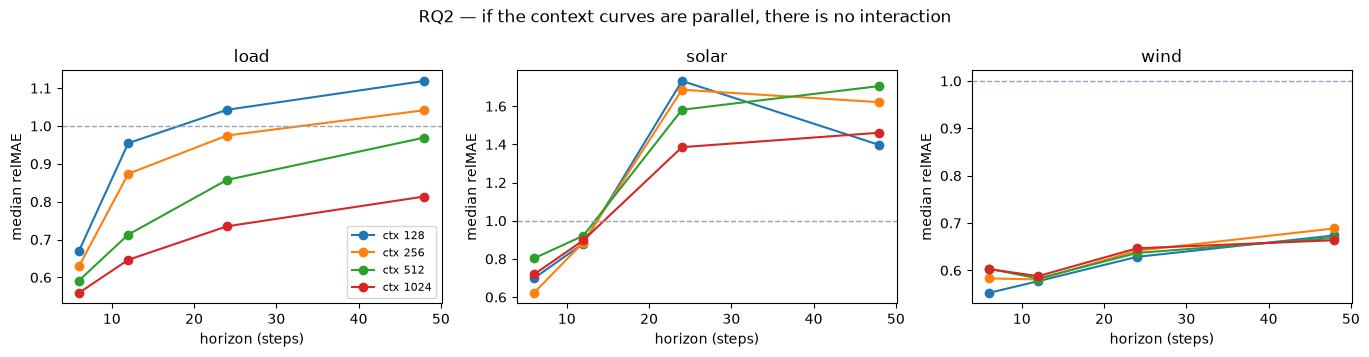

In [7]:
ets = sorted(cl.etype.unique())
fig, axes = plt.subplots(1, len(ets), figsize=(4.6*len(ets), 3.6), squeeze=False)
for ax, et in zip(axes[0], ets):
    sub = cl[cl.etype == et]
    for ctx, g in sub.groupby("context_steps"):
        y = g.groupby("horizon_steps")["relMAE"].median()
        ax.plot(y.index, y.values, marker="o", label=f"ctx {ctx}")
    ax.axhline(1.0, color="#94a3b8", ls="--", lw=1)
    ax.set_title(et); ax.set_xlabel("horizon (steps)"); ax.set_ylabel("median relMAE")
axes[0][0].legend(fontsize=8)
plt.suptitle("RQ2 — if the context curves are parallel, there is no interaction")
plt.tight_layout(); plt.show()

## 4. Is there actually an interaction?

Parallel lines in the plot mean context and horizon act independently. A formal test:
fit `log relMAE ~ log(context) + log(horizon)` and compare against the same model with the
interaction term added. If the interaction does not improve the fit, RQ2's second half has
a clean negative answer — worth stating plainly rather than leaving implicit.

In [8]:
import statsmodels.formula.api as smf
d = cl.dropna(subset=["relMAE"]).copy()
d["y"] = np.log10(d.relMAE.replace(0, np.nan))
d["lc"] = np.log2(d.context_steps)
d["lh"] = np.log2(d.horizon_steps)
d = d.dropna(subset=["y"])

rows = []
for et, g in d.groupby("etype"):
    m0 = smf.ols("y ~ lc + lh", data=g).fit()
    m1 = smf.ols("y ~ lc * lh", data=g).fit()
    lr = m1.compare_lr_test(m0)
    rows.append({"etype": et, "n": len(g),
                 "coef_context": m0.params.get("lc", np.nan),
                 "coef_horizon": m0.params.get("lh", np.nan),
                 "interaction_coef": m1.params.get("lc:lh", np.nan),
                 "R2_no_interaction": m0.rsquared, "R2_with": m1.rsquared,
                 "p_interaction": lr[1]})
inter = pd.DataFrame(rows)
print(inter.round(4).to_string(index=False))
print("\ncoef_context vs coef_horizon: the larger absolute value is the stronger lever.")
print("p_interaction < 0.05 means the horizon effect genuinely depends on context.")
inter.to_csv("refined_stage3h_interaction_test.csv", index=False)

etype     n  coef_context  coef_horizon  interaction_coef  R2_no_interaction  R2_with  p_interaction
 load  7200       -0.0519        0.0678           -0.0111             0.0417   0.0426         0.0097
solar  3924       -0.0327        0.2028           -0.0099             0.0905   0.0907         0.2892
 wind 11796        0.0282        0.0657           -0.0082             0.0141   0.0143         0.1058

coef_context vs coef_horizon: the larger absolute value is the stronger lever.
p_interaction < 0.05 means the horizon effect genuinely depends on context.


## 5. In duration units

RQ2 asks for both observation counts and real-world duration. Same surface, read the way
an operator would.

In [9]:
t = (cl.groupby(["etype", "context_steps", "horizon_steps"])
       .agg(history=("history_minutes", "first"), lead=("lead_minutes", "first"),
            relMAE=("relMAE", "median"), n=("relMAE", "size")).reset_index())
t["history"] = t.history.map(C.human_duration)
t["lead"] = t.lead.map(C.human_duration)
print(t.round(3).to_string(index=False))

etype  context_steps  horizon_steps history   lead  relMAE    n
 load            128              6   2.7 d  3.0 h   0.669  450
 load            128             12   2.7 d  6.0 h   0.955  450
 load            128             24   2.7 d 12.0 h   1.043  450
 load            128             48   2.7 d  1.0 d   1.119  450
 load            256              6   5.3 d  3.0 h   0.629  450
 load            256             12   5.3 d  6.0 h   0.874  450
 load            256             24   5.3 d 12.0 h   0.975  450
 load            256             48   5.3 d  1.0 d   1.042  450
 load            512              6  10.7 d  3.0 h   0.592  450
 load            512             12  10.7 d  6.0 h   0.713  450
 load            512             24  10.7 d 12.0 h   0.858  450
 load            512             48  10.7 d  1.0 d   0.969  450
 load           1024              6  21.3 d  3.0 h   0.559  450
 load           1024             12  21.3 d  6.0 h   0.646  450
 load           1024             24  21.

## 6. What to report

- The two coefficients from section 4 settle the first half of RQ2: which lever matters.
  Across 3B and 3C, horizon dominated and context did almost nothing — this tests that
  properly, on a balanced grid, with adequate windows per cell.
- `p_interaction` settles the second half. A null here is a legitimate finding: it means
  the optimal context does **not** depend on how far ahead you forecast, which simplifies
  the deployment advice considerably.
- Quote the window plan from section 1 in the methodology. Saying every cell rests on at
  least 20 windows and at least 14 days is one sentence that closes an obvious line of
  attack.